In [2]:
import itertools

import lmfit
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr

# Resonator fitting

## Model

In [22]:
class ResonatorTransmissionModel(lmfit.model.Model):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(resonator_transmission_model_function, *args, **kwargs)
        self.set_param_hint("Q", min=0)
        self.set_param_hint("background_magnitude", min=0)

    def guess(self, data, f, **kwargs) -> lmfit.parameter.Parameters:
        data = np.asarray(data)
        f = np.asarray(f)
        
        data_magn = np.abs(data)
        data_phase = np.unwrap(np.angle(data))

        fr_index = np.argmin(data_magn)
        fr = f[fr_index]
        background_magnitude = np.max(data_magn)
        
        m, c = np.polyfit(f, data_phase, deg=1)
        phase_delay = -m
        background_phase = np.mod(c + np.pi, 2*np.pi) - np.pi
        
        delta_f = np.abs(f - fr)
        idx = np.argsort(delta_f)
        delta_f = delta_f[idx]
        data_magn_folded = data_magn[idx]
        
        half_max = 0.5 * data_magn[fr_index] + 0.5 * background_magnitude
        hwhm = delta_f[np.argmax(data_magn_folded > half_max)]
        Q = fr/(2*hwhm)

        background_fr = background_transmission_model_function(
            fr,
            fr=fr,
            magnitude=background_magnitude,
            phase=background_phase,
            phase_delay=phase_delay,
        )
        Qe = Q/(1 - data[fr_index]/background_fr)
         
        self.set_param_hint("fr", value=fr, min=np.min(f), max=np.max(f))
        self.set_param_hint("Q", value=Q)
        self.set_param_hint("Qe_re", value=Qe.real)
        self.set_param_hint("Qe_im", value=Qe.imag)
        self.set_param_hint("background_magnitude", value=background_magnitude)
        self.set_param_hint("background_slope", value=0.0)
        self.set_param_hint("background_phase", value=background_phase)
        self.set_param_hint("phase_delay", value=phase_delay)
        
        params = self.make_params()
        return lmfit.models.update_param_vals(params, self.prefix, **kwargs)


def background_transmission_model_function(
        f,
        fr: float,  # Center frequency for background slope
        magnitude: float,  # Background transmission amplitude
        slope: float = 0.0,  # Background transmission slope
        phase: float = 0.0,  # Background transmission phase
        phase_delay: float = 0.0,  # Phase propagation delay
) -> complex:
    S21 = (
        (1 + slope * (f - fr))
        * magnitude
        * np.exp(1j*phase)
        * np.exp(-1j*phase_delay * f)
    )
    return S21


def resonator_transmission_model_function(
        f: float,
        fr: float,  # Resonator frequency
        Q: float,  # Total quality factor
        Qe_re: float,  # Coupling quality factor real
        Qe_im: float,  # and imaginary
        background_magnitude: float,  # Background transmission amplitude
        background_slope: float = 0.0,  # Background transmission slope
        background_phase: float = 0.0,  # Background transmission phase
        phase_delay: float = 0.0,  # Phase propagation delay
) -> complex:
    Qe = Qe_re + 1j*Qe_im

    background = background_transmission_model_function(
        f,
        fr=fr,
        magnitude=background_magnitude,
        phase=background_phase,
        slope=background_slope,
        phase_delay=phase_delay,
    )
    resonator = 1 - (Q * Qe**-1 / (1 + 2j * Q * (f - fr) / fr))

    S21 = background * resonator

    return S21

## Fit measured transmission data

In [ ]:
dataset = xr.load_dataset("Data\Cross_talk_original.hdf5")

In [46]:
model = ResonatorTransmissionModel()
def fit_transmission(data, f, fix_params=None):
    guess_params = model.guess(data, f=f)
    if fix_params is not None:
        for name, value in fix_params.items():
            guess_params[name].value = value
            guess_params[name].vary = False
    fit_result = model.fit(data, f=f, params=guess_params)
    best_values = fit_result.best_values
    return (
        best_values['fr'],
        best_values['Q'],
        best_values['Qe_re'],
        best_values['Qe_im'],
        best_values['background_magnitude'],
        best_values['background_slope'],
        best_values['background_phase'],
        best_values['phase_delay'],
    )

# First fit part of the data to extract the background magnitude, slope and phase delay.
ds = dataset.isel(x=slice(None, None, 10), y=slice(None, None, 20))
result_partial = xr.apply_ufunc(
    fit_transmission,
    ds.S21_real + 1j*ds.S21_imag,
    ds.frequency,
    input_core_dims=[['frequency'], ['frequency']],
    output_core_dims=[[]] * 8,
    vectorize=True,
)

dataset.attrs.update(dict(
    background_magnitude=result_partial[4].median().item(),
    background_slope=result_partial[5].median().item(),
    phase_delay=result_partial[7].median().item(),
))

In [47]:
# Fit the rest of the data assuming a constant background magnitude, slope and phase delay.
result = xr.apply_ufunc(
    fit_transmission,
    dataset.S21_real + 1j*dataset.S21_imag,
    dataset.frequency,
    input_core_dims=[['frequency'], ['frequency']],
    output_core_dims=[[]] * 8,
    vectorize=True,
    kwargs=dict(
        fix_params=dict(
            background_magnitude=dataset.attrs['background_magnitude'],
            background_slope=dataset.attrs['background_slope'],
            phase_delay=dataset.attrs['phase_delay'],
        )
    )
)
orig_dataset = dataset.copy()

dataset['fr'] = result[0]
dataset.fr.attrs['units'] = 'GHz'
dataset['Q'] = result[1]
dataset['Qe_real'] = result[2]
dataset['Qe_imag'] = result[3]
dataset['background_phase'] = result[6]
dataset.fr.attrs['units'] = 'GHz'

# Somehow xr.apply_ufunc() loses the coordinate attributes,
# so we manually restore them.
dataset.x.attrs.update(orig_dataset.x.attrs)
dataset.y.attrs.update(orig_dataset.y.attrs)
dataset.frequency.attrs.update(orig_dataset.frequency.attrs)

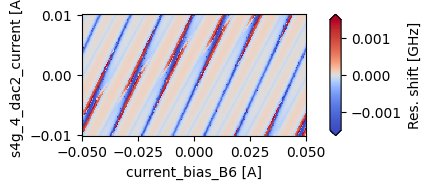

In [48]:
# Visualize the fitted resonator frequencies as a heatmap.
fig, (ax, cax) = plt.subplots(
    figsize=(85/25.4, 40/25.4),
    ncols=2,
    width_ratios=[1, 0.05],
)
quadmesh = (dataset.fr - dataset.fr.median()).plot(
    ax=ax,
    # Use a non-linear norm to see small resonator shifts better.
    norm=mpl.colors.AsinhNorm(0.2e-3, -1.5e-3, 1.5e-3),
    cmap='coolwarm',
    rasterized=True,
    add_colorbar=False,
)
fig.colorbar(
    quadmesh,
    cax,
    label='Res. shift [GHz]',
    extend='both',
)
cax.set_yscale('linear')

In [50]:
# Save the results of the transmission data fitting.
dataset.to_netcdf("Crosstalk_original_fitted.hdf5")

# Crosstalk determination

In [ ]:
# Load fitted transmission data
dataset = xr.load_dataset("Crosstalk_original_fitted.hdf5")
dataset['S21'] = dataset.S21_real + 1j*dataset.S21_imag

In [34]:
dataset

<xarray.Dataset> Size: 262MB
Dimensions:           (y: 101, x: 401, frequency: 201)
Coordinates:
  * y                 (y) float64 808B -0.01 -0.0098 -0.0096 ... 0.0098 0.01
  * x                 (x) float64 3kB -0.05 -0.04975 -0.0495 ... 0.04975 0.05
  * frequency         (frequency) float64 2kB 5.224 5.224 5.224 ... 5.244 5.244
Data variables:
    sweep_index       (y, x) int32 162kB 0 1 2 3 4 ... 40497 40498 40499 40500
    S21_real          (frequency, y, x) float64 65MB 1.723 1.73 ... -1.197 -1.2
    S21_imag          (frequency, y, x) float64 65MB -0.1501 -0.1357 ... -0.8519
    fr                (y, x) float64 324kB 5.235 5.234 5.234 ... 5.234 5.234
    Q                 (y, x) float64 324kB 2.973e+03 2.918e+03 ... 5.039e+03
    Qe_real           (y, x) float64 324kB 4.964e+03 5.169e+03 ... 5.245e+03
    Qe_imag           (y, x) float64 324kB 1.609e+03 1.183e+03 ... 1.501e+03
    background_phase  (y, x) float64 324kB -2.524 -2.517 ... -2.468 -2.468
    S21               (frequency, y, x) complex128 130MB (1.723030588361952-0...
Attributes:
    tuid:     20250409-135510-023-090d2f
    name:     Single tone spectroscopy vs current, B6 (5.234 GHz, 40 mV)

## Find periodic features

In [35]:
# Kernel center in units of amps
kernel_center = (.04, -4.5e-3)

# Kernel size in number of pixels
kernel_size = (47, 19)

kernel_center_indices = (
    abs(dataset.x - kernel_center[0]).argmin().item(),
    abs(dataset.y - kernel_center[1]).argmin().item(),
)
kernel_extents = (  # (xmin, xmax, ymin, ymax)
    dataset.x[kernel_center_indices[0] - kernel_size[0]//2].item(),
    dataset.x[kernel_center_indices[0] + kernel_size[0]//2 + 1].item(),
    dataset.y[kernel_center_indices[1] - kernel_size[1]//2].item(),
    dataset.y[kernel_center_indices[1] + kernel_size[1]//2 + 1].item(),
)

In [36]:
kernel = dataset.S21.loc[:,kernel_extents[2]:kernel_extents[3],kernel_extents[0]:kernel_extents[1]].data

S21_rolling = dataset.S21.rolling(
    y=kernel.shape[1],
    x=kernel.shape[2],
    center=True,
).construct(dict(x='window_x', y='window_y'))

# Perform a correlation with the kernel
S21_matched = abs(xr.apply_ufunc(
    lambda a, v: np.einsum("...ijk,ijk", a, v),
    S21_rolling, 
    kernel.conj(),
    input_core_dims=[
        ['frequency', 'window_y', 'window_x'],
        ['window_y', 'window_x'],
    ],
))

S21_matched_masked = S21_matched.copy()
vertices = np.empty((0, 2))
# Find the top 2 highest "similarity scores" (highest correlation)
for _ in range(2):
    i, j = np.unravel_index(S21_matched_masked.argmax(), S21_matched_masked.shape)
    y = S21_matched_masked.y[i].item()
    x = S21_matched_masked.x[j].item()
    vertices = np.append(vertices, [(x, y)], axis=0)

    # Remove a region that is twice the kernel size around each peak to avoid multiple triggers.
    S21_matched_masked = S21_matched_masked.where(~(
        (abs(S21_matched_masked.x - x) <= (kernel_extents[1] - kernel_extents[0]))
        & (abs(S21_matched_masked.y - y) <= (kernel_extents[3] - kernel_extents[2]))
    ))

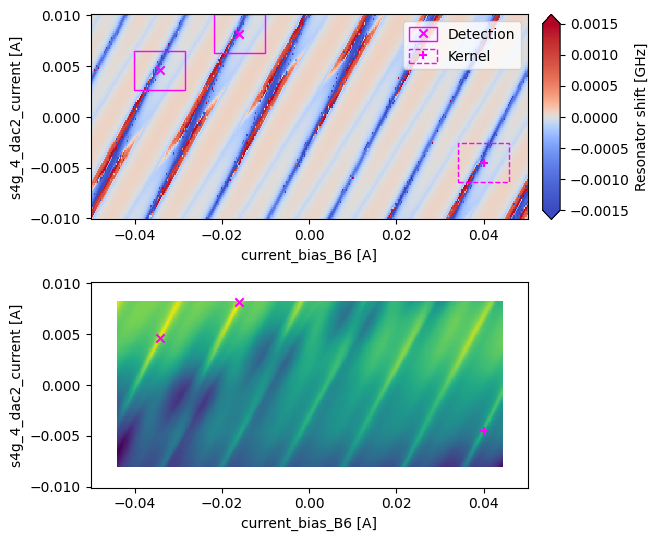

In [37]:
fig, axs = plt.subplots(
    figsize=(2*85/25.4, 2*70/25.4),
    nrows=2,
    ncols=2,
    width_ratios=[1, 0.04],
)

ax, cax = axs[0]
ax.set_title("Detected repeated features")
quadmesh = (dataset.fr - dataset.fr.median()).plot(
    ax=ax,
    norm=mpl.colors.AsinhNorm(0.2e-3, -1.5e-3, 1.5e-3),
    cmap='coolwarm',
    rasterized=True,
    add_colorbar=False,
)
fig.colorbar(
    quadmesh,
    cax,
    label='Resonator shift [GHz]',
    extend='both',
)
cax.set_yscale('linear')

kernel_rect_patch = None
detection_marker = ax.scatter(*vertices.T, c='fuchsia', marker='x')
kernel_marker = ax.scatter(*kernel_center, c='fuchsia', marker='+')
for (vx, vy) in [*vertices, kernel_center]:
    rect_width = kernel_extents[1] - kernel_extents[0]
    rect_height = kernel_extents[3] - kernel_extents[2]
    if (vx, vy) == kernel_center:
        linestyle = '--'
    else:
        linestyle = '-'
    rect_patch = mpl.patches.Rectangle(
        (vx - rect_width/2, vy - rect_height/2),
        width=rect_width,
        height=rect_height,
        fill=None,
        edgecolor='fuchsia',
        linestyle=linestyle,
    )
    ax.add_patch(rect_patch)
    if linestyle == '--':
        # Save this rect patch to re-use when making the legend
        kernel_rect_patch = rect_patch
    else:
        detection_rect_patch = rect_patch

ax.legend(
    [(detection_rect_patch, detection_marker), (kernel_rect_patch, kernel_marker)],
    ["Detection", "Kernel"],
    handleheight=1.2,
)

ax, cax = axs[1]
ax.set_title("Matched filter")
cax.set_axis_off()
quadmesh = S21_matched.plot(
    ax=ax,
    add_colorbar=False,
)
ax.scatter(*vertices.T, c='fuchsia', marker='x')
ax.scatter(*kernel_center, c='fuchsia', marker='+')

fig.tight_layout()

In [38]:
from matplotlib.patches import FancyArrowPatch


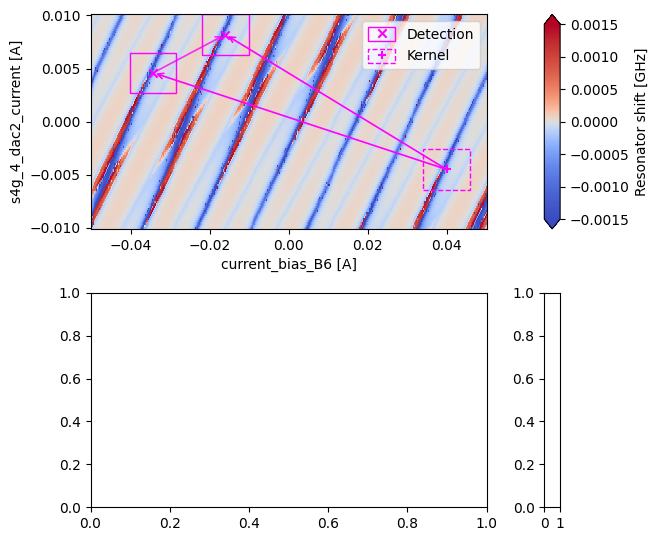

In [39]:
fig, axs = plt.subplots(
    figsize=(2*85/25.4, 2*70/25.4),
    nrows=2,
    ncols=2,
    width_ratios=[1, 0.04],
)

ax, cax = axs[0]
ax.set_title("Detected repeated features")
quadmesh = (dataset.fr - dataset.fr.median()).plot(
    ax=ax,
    norm=mpl.colors.AsinhNorm(0.2e-3, -1.5e-3, 1.5e-3),
    cmap='coolwarm',
    rasterized=True,
    add_colorbar=False,
)
fig.colorbar(
    quadmesh,
    cax,
    label='Resonator shift [GHz]',
    extend='both',
)
cax.set_yscale('linear')

kernel_rect_patch = None
detection_marker = ax.scatter(*vertices.T, c='fuchsia', marker='x')
kernel_marker = ax.scatter(*kernel_center, c='fuchsia', marker='+')

for vx, vy in vertices:
    arrow = FancyArrowPatch(
        posA=kernel_center,
        posB=(vx, vy),
        arrowstyle="->",
        color="fuchsia",
        mutation_scale=10,
        lw=1.2,
    )
    ax.add_patch(arrow)
for (vx, vy) in [*vertices, kernel_center]:
    rect_width = kernel_extents[1] - kernel_extents[0]
    rect_height = kernel_extents[3] - kernel_extents[2]
    if (vx, vy) == kernel_center:
        linestyle = '--'
    else:
        linestyle = '-'
    rect_patch = mpl.patches.Rectangle(
        (vx - rect_width/2, vy - rect_height/2),
        width=rect_width,
        height=rect_height,
        fill=None,
        edgecolor='fuchsia',
        linestyle=linestyle,
    )
    ax.add_patch(rect_patch)
    if linestyle == '--':
        # Save this rect patch to re-use when making the legend
        kernel_rect_patch = rect_patch
    else:
        detection_rect_patch = rect_patch

from itertools import combinations

for (i, (x0, y0)), (j, (x1, y1)) in combinations(enumerate(vertices), 2):
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="<-",
            color='fuchsia',
            lw=1.2,
            alpha=0.8,
        ),
    )

ax.legend(
    [(detection_rect_patch, detection_marker), (kernel_rect_patch, kernel_marker)],
    ["Detection", "Kernel"],
    handleheight=1.2,
)


fig.tight_layout()

## Determine unit cell

In [40]:
# Create all combination of vectors that translate periodically.
lattice_vectors = []
for p0, p1 in itertools.combinations([*vertices, kernel_center], 2):
    lattice_vectors.append(p1 - p0)

# Define the basis as the pair of vectors with maximum parallelogram area.
basis_vectors = max(
    itertools.combinations(lattice_vectors, 2),
    key=lambda uv: abs(uv[0][0]*uv[1][1] - uv[0][1]*uv[1][0]),
)

# Sort the basis so that the first vector is most aligned with the X axis.
basis_vectors = sorted(basis_vectors, key=lambda v: abs(v[0]), reverse=True)

# The basis vectors are now stored in the columns.
basis_vectors = np.column_stack(basis_vectors)

# Make the x-direction positive
basis_vectors *= np.sign(basis_vectors[0])

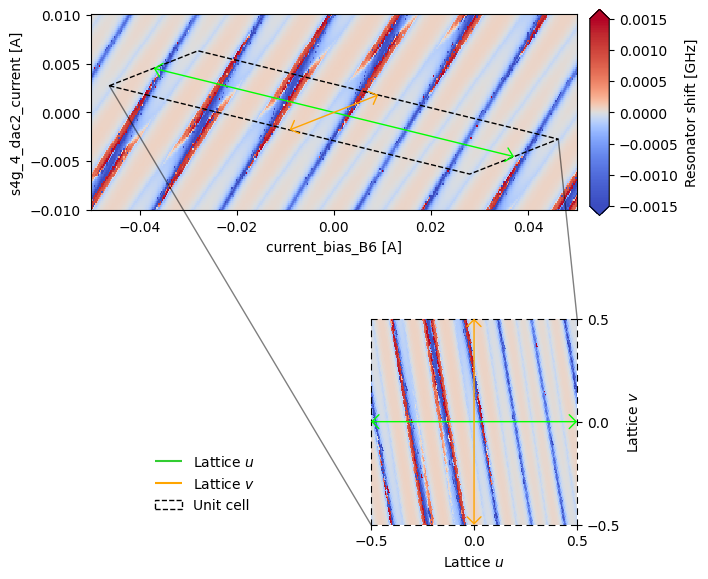

In [41]:
fig, axs = plt.subplots(
    figsize=(2*85/25.4, 2*85/25.4),
    nrows=2,
    ncols=2,
    width_ratios=[1, 0.04],
    height_ratios=[1, 1],
)

ax, cax = axs[0]
quadmesh = (dataset.fr - dataset.fr.median()).plot(
    ax=ax,
    norm=mpl.colors.AsinhNorm(0.2e-3, -1.5e-3, 1.5e-3),
    cmap='coolwarm',
    rasterized=True,
    add_colorbar=False,
)
fig.colorbar(
    quadmesh,
    cax,
    label='Resonator shift [GHz]',
    extend='both',
)
cax.set_yscale('linear')

annot0 = ax.annotate(
    "",
    -basis_vectors[:, 0]/2,
    +basis_vectors[:, 0]/2,
    arrowprops=dict(
        arrowstyle='<->,head_width=0.5,head_length=0.5',
        shrinkA=0.0,
        shrinkB=0.0,
        ec='lime',
    ),
)
annot1 = ax.annotate(
    "",
    -basis_vectors[:, 1]/2,
    +basis_vectors[:, 1]/2,
    arrowprops=dict(
        arrowstyle='<->,head_width=0.5,head_length=0.5',
        shrinkA=0.0,
        shrinkB=0.0,
        ec='orange',
    ),
)
unit_cell_boundary = mpl.path.Path(
    [
        -basis_vectors[:, 0]/2 - basis_vectors[:, 1]/2,
        -basis_vectors[:, 0]/2 + basis_vectors[:, 1]/2,
        +basis_vectors[:, 0]/2 + basis_vectors[:, 1]/2,
        +basis_vectors[:, 0]/2 - basis_vectors[:, 1]/2,
        -basis_vectors[:, 0]/2 - basis_vectors[:, 1]/2,
    ],
    closed=True
)
path_patch = mpl.patches.PathPatch(unit_cell_boundary, fc='none', ec='black', ls='--')
ax.add_patch(path_patch)
ax.legend(
    [
        mpl.collections.LineCollection([], color='limegreen'),
        mpl.collections.LineCollection([], color='orange'),
        path_patch,
    ],
    [r"Lattice $u$", r"Lattice $v$", "Unit cell"],
    loc='lower right',
    bbox_to_anchor=(-0.5, 0),
    bbox_transform=axs[1, 0].transAxes,
    frameon=False,
)
ax.set_aspect(2)

ax, cax = axs[1]
cax.set_axis_off()

# Transform the data so that basis_vectors[:, 0] lines up with (1, 0)
# and basis_vectors[:, 1] lines up with (0, 1) in the new coordinates.
skew = np.column_stack([
    basis_vectors,
    (0, 0),
])
ax.pcolormesh(
    dataset.x,
    dataset.y,
    (dataset.fr - dataset.fr.median()),
    transform=(
        mpl.transforms.Affine2D(np.linalg.inv(np.block([
            [skew],
            [0, 0, 1],
        ])))
        + ax.transData
    ),
    cmap='coolwarm',
    norm=mpl.colors.AsinhNorm(0.2e-3, -1.5e-3, 1.5e-3),
    rasterized=True,
)
annot0 = ax.annotate(
    "",
    (-0.5, 0.0),
    (+0.5, 0.0),
    arrowprops=dict(
        arrowstyle='<->,head_width=0.5,head_length=0.5',
        shrinkA=0.0,
        shrinkB=0.0,
        ec='lime',
    ),
)
annot1 = ax.annotate(
    "",
    (0.0, -0.5),
    (0.0, +0.5),
    arrowprops=dict(
        arrowstyle='<->,head_width=0.5,head_length=0.5',
        shrinkA=0.0,
        shrinkB=0.0,
        ec='orange',
    ),
)

# Draw lines connecting the boundary of the bottom axes to the top axes.
for (x, y) in [(-0.5, -0.5), (0.5, 0.5)]:
    ax.annotate(
        "",
        (x, y),
        basis_vectors @ (x, y),
        xycoords='data',
        textcoords=axs[0,0].transData,
        arrowprops=dict(
            arrowstyle='-',
            shrinkA=0.0,
            shrinkB=0.0,
            ec='black',
            alpha=0.5,
        ),
    )

ax.set_xlabel("Lattice $u$")
ax.set_ylabel("Lattice $v$")
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.5, 0.5)
ax.set_xticks([-0.5, 0, 0.5])
ax.set_yticks([-0.5, 0, 0.5])
ax.yaxis.set_label_position('right')
ax.tick_params(labelleft=False, left=False, labelright=True, right=True)
ax.set_aspect(1)
ax.set_anchor('E')
ax.spines[:].set_linestyle((0, (5, 5)))
fig.subplots_adjust(
    wspace=0.05,
    hspace=0.50,
)

# fig.tight_layout()
# plt.gca().set_aspect(1)

## Virtual crosstalk compensation

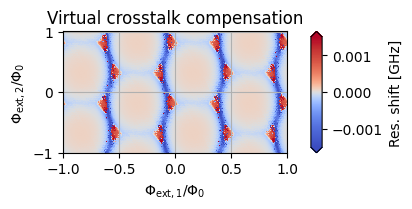

In [12]:
# Transform unit cell into "conventional" cell coordinates
# These numbers were obtained by eye
M = np.array([
    [   3,  1],
    [ -20, -6],
])

phi_grid = np.array(np.meshgrid(
    np.linspace(-1, 1, 1001),
    np.linspace(-1, 1, 1001),
))

phi_grid = np.rollaxis(phi_grid, 0, 3)[..., None]
lattice_grid = M @ phi_grid
# Wrap points within the fundamental domain.
lattice_grid = np.mod(lattice_grid + 0.5, 1) - 0.5
physical_grid = basis_vectors @ lattice_grid

# Interpolate resonator frequencies onto the sampling grid
fr_interp = dataset.fr.interp(
    x=xr.DataArray(physical_grid[..., 0, 0], dims=['x', 'y']),
    y=xr.DataArray(physical_grid[..., 1, 0], dims=['x', 'y']),
    method='nearest',
)

fig, (ax, cax) = plt.subplots(
    figsize=(85/25.4, 40/25.4),
    ncols=2,
    width_ratios=[1, 0.05],
)

quadmesh = ax.pcolormesh(
    phi_grid[..., 0, 0],
    phi_grid[..., 1, 0],
    fr_interp - fr_interp.median(),
    cmap='coolwarm',
    norm=mpl.colors.AsinhNorm(0.2e-3, -1.5e-3, 1.5e-3),
    rasterized=True,
)
ax.grid()
ax.set_xlabel(r"$\Phi_{\mathrm{ext},1}/\Phi_0$")
ax.set_ylabel(r"$\Phi_{\mathrm{ext},2}/\Phi_0$")
ax.set_title("Virtual crosstalk compensation")
fig.colorbar(
    quadmesh,
    cax,
    label='Res. shift [GHz]',
    extend='both',
)
cax.set_yscale('linear')

In [13]:
# The columns are the orthogonal current bias directions.
# Because there is a lot of crosstalk, they are very close to parallel.
basis_vectors @ M

array([[-0.14225, -0.03525],
       [-0.0993 , -0.0307 ]])